<a href="https://colab.research.google.com/github/slyamo/APT3025_Datasets/blob/main/APT3025_Practical_Sylvia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

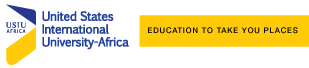
# Course: APT3025 – Applied Machine Learning
# Student Name: Sylvia Amo Owino
# Student ID: 663834
# Course Code: APT3025VA
# Course Title: Applied Machine Learning
# Practical : Data Preprocessing, Feature Engineering,Principal Component Analysis (PCA), NLP and Reinforcement Learning Techniques
# Lecturer: Dr. Peter Juma

This notebook uses different datasets for each section to best demonstrate each technique:
- **Part 1 – Data Cleaning**: Titanic Dataset
- **Part 2 – Feature Engineering**: PCOS Dataset
- **Part 3 – PCA**: Wine Quality Dataset
- **Part 4 – Bag of Words**: IMDB Movie Reviews Dataset
- **Part 5 – Reinforcement Learning**: Maze Environment (no dataset required)


# Shared Imports for each part


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


---
# Part 1: Data Cleaning
### Dataset: Titanic
### Source: https://www.kaggle.com/datasets/yasserh/titanic-dataset

Data cleaning includes the process of identifying and cleaning out any unwanted data such as missing, duplicate, and irrelevant data.

- The data collected may be noisy and incomplete and may not be consistent with the data collected so far, which may affect the accuracy of the model.
- The aim of data cleaning is to make the data accurate and consistent and free from errors.
- Clean data is also essential for Exploratory Data Analysis (EDA), which makes the data more interpretable so that the right actions can be performed based on the data.

The following steps need to be performed for effective data cleaning:
- Remove Unwanted Observations: This includes the removal of duplicate data and irrelevant data.
- Fix Structural Errors: This includes the standardization of the data collected.
- Manage Outliers: This includes the handling of extreme values that may affect the data collected.
- Handle Missing Data: This includes the handling of missing values in the data collected.

# Step 1: Import Libraries and Load Dataset

In [3]:
from google.colab import files

print("Upload Titanic-Dataset.csv")
uploaded = files.upload()

df_titanic = pd.read_csv('Titanic-Dataset.csv')
df_titanic.info()
df_titanic.head()


Upload Titanic-Dataset.csv


Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 2: Check for Duplicate Rows

df.duplicated(): Returns a boolean series indicating duplicate rows

In [15]:
print("Duplicate rows found:", df_titanic.duplicated())


Duplicate rows found: 0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 889, dtype: bool


# Step 3: Identify Column Data Types


* Uses list comprehension to separate columns by data type
* .dtype checks the type of each column
* object type represents categorical (text) data
* Non-object types represent numerical data


In [5]:
cat_col = [col for col in df_titanic.columns if df_titanic[col].dtype == 'object']
num_col = [col for col in df_titanic.columns if df_titanic[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)


Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


# Step 4: Count Unique Values in the Categorical Columns



* df[cat_col].nunique() Selects categorical columns and returns the number of unique values in each column.



In [6]:
df_titanic[cat_col].nunique()


,0
Name,891
Sex,2
Ticket,681
Cabin,147
Embarked,3


# Step 5: Calculate Missing Values as Percentage

round((df_titanic.isnull().sum() / df_titanic.shape[0]) * 100, 2)

* Uses .isnull() to identify
missing values in the DataFrame
* .sum() counts total missing values per column
* df_titanic.shape[0] gives the total number of rows
* Dividing missing values by total rows and multiplying by 100 calculates the percentage of missing data
* round(..., 2) rounds the percentages to 2 decimal places for readability













In [7]:
round((df_titanic.isnull().sum() / df_titanic.shape[0]) * 100, 2)


,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


# Step 6: Drop Irrelevant or Data-Heavy Missing Columns




* df_titanic.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True): removes the columns `Name`, `Ticket`, and `Cabin` from the DataFrame.
* df_titanic.dropna(subset=['Embarked'], inplace=True): deletes rows where the `Embarked` column has missing values
* df_titanic['Age'].fillna(df_titanic['Age'].mean(), inplace=True): replaces missing values in the `Age` column with the column’s mean value.











In [8]:
df_titanic.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)
df_titanic.dropna(subset=['Embarked'], inplace=True)
df_titanic['Age'].fillna(df_titanic['Age'].mean(), inplace=True)

print("Missing values after cleaning:")
print(df_titanic.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_7834/1554216578.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic['Age'].fillna(df_titanic['Age'].mean(), inplace=True)


# Step 7: Detect Outliers with Box Plot



* plt.boxplot(df_titanic['Age'], vert=False): creates a box plot of the Age column, displayed horizontally because vert=False.
* plt.ylabel('Variable'):sets the label for the y-axis.
* plt.xlabel('Age'): sets the label for the x-axis.
plt.title('Box Plot'): sets the title of the plot.
* plt.show(): renders and displays the plot.

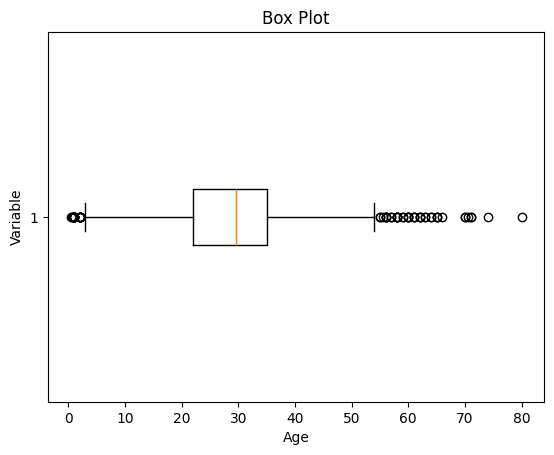

In [9]:
plt.boxplot(df_titanic['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()


# Step 8: Calculate Outlier Boundaries and Remove Them



* mean = df_titanic['Age'].mean() : calculates the average age in the dataset
* std = df_titanic['Age'].std() : calculates the standard deviation of the Age column
* lower_bound = mean - 2 * std : defines the lower limit for acceptable ages (2 standard deviations below the mean)

* upper_bound = mean + 2 * std : defines the upper limit for acceptable ages (2 standard deviations above the mean)

* df_titanic_clean = df_titanic[(df_titanic['Age'] >= lower_bound) & (df_titanic['Age'] <= upper_bound)] : filters the DataFrame to keep only rows where Age is within the bounds (removes outliers)


In [18]:
mean = df_titanic['Age'].mean()
std  = df_titanic['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Mean: ', mean)
print('Standard Deviation: ', std)

print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

df_titanic_clean = df_titanic[(df_titanic['Age'] >= lower_bound) & (df_titanic['Age'] <= upper_bound)]



Mean:  29.642092696629216
Standard Deviation:  12.968346294351784
Lower Bound: 3.705400107925648
Upper Bound: 55.578785285332785


# Step 9: Impute Missing Data Again if Any



* df_titanic_clean2 = df_titanic_clean.fillna(df_titanic_clean['Age'].mean()) : fills any remaining missing values in the DataFrame with the mean of the Age column

* df_titanic_clean2.isnull().sum() : counts the number of missing values in each column after filling



In [20]:
df_titanic_clean2 = df_titanic_clean.fillna(df_titanic_clean['Age'].mean())
df_titanic_clean2.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# Step 10: Recalculate Outlier Bounds and Remove Outliers from the Updated Data

* mean = df_titanic_clean2['Age'].mean() : calculates the average age in the cleaned DataFrame
* std = df_titanic_clean2['Age'].std() : calculates the standard deviation of the Age column
* lower_bound = mean - 2 * std : sets the lower limit for age (2 standard deviations below the mean)
* upper_bound = mean + 2 * std : sets the upper limit for age (2 standard deviations above the mean)
* df_titanic_recalculate = df_titanic_clean2[(df_titanic_clean2['Age'] >= lower_bound) & (df_titanic_clean2['Age'] <= upper_bound)] : filters the DataFrame again to remove any new outliers based on the recalculated bounds


In [22]:
mean = df_titanic_clean2['Age'].mean()
std = df_titanic_clean2['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Mean: ', mean)
print('Standard Deviation: ', std)
print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df_titanic_recalculate = df_titanic_clean2[(df_titanic_clean2['Age'] >= lower_bound) & (df_titanic_clean2['Age'] <= upper_bound)]

Mean:  29.141474308530295
Standard Deviation:  10.081242652179407
Lower Bound : 8.978989004171481
Upper Bound : 49.30395961288911


# Step 11: Data Validation and Verification

* X = df_titanic_clean2[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']] : selects the feature columns for modeling and stores them in X
* Y = df_titanic_clean2['Survived'] : selects the target column (what we want to predict) and stores it in Y


In [26]:
X = df_titanic_clean2[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
Y = df_titanic_clean2['Survived']

print("Features shape: ", X.shape)
print("Target shape:  ", Y.shape)


Features shape:  (821, 7)
Target shape:   (821,)


# Step 12: Data Formatting (Min-Max Scaling)



* from sklearn.preprocessing import MinMaxScaler : imports **MinMaxScaler** from scikit-learn, which scales numerical data to a specific range
* scaler = MinMaxScaler(feature_range=(0, 1)) : creates a scaler object that will scale values to the range 0 to 1
* num_col_ = [col for col in X.columns if X[col].dtype != 'object'] : selects the numerical columns from X
* X1 = X.copy() : makes a copy of X so the original data isn’t modified
* X1[num_col_] = scaler.fit_transform(X1[num_col_]) : scales all numerical columns in X1 to the 0–1 range
* X1.head() : displays the first 5 rows of the scaled features




In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

num_col_ = [col for col in X.columns if X[col].dtype != 'object']
X1 = X.copy()
X1[num_col_] = scaler.fit_transform(X1[num_col_])
X1.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.349515,0.125,0.0,0.014151,S
1,0.0,female,0.660194,0.125,0.0,0.139136,C
2,1.0,female,0.427184,0.000,0.0,0.015469,S
3,0.0,female,0.601942,0.125,0.0,0.103644,S
4,1.0,male,0.601942,0.000,0.0,0.015713,S


---
# Part 2: Feature Engineering
### Dataset: PCOS
### Source: https://www.kaggle.com/datasets/samikshadalvi/pcos-diagnosis-dataset

Feature engineering is the process of creating, transforming or selecting important features from raw data to improve model performance. These features help the model capture useful patterns and relationships in the data.

It contributes to model building in the following ways:
- Better Pattern Learning: Well-designed features help the model learn complex patterns more effectively.
- Improved Prediction Accuracy: Removing noise and irrelevant information improves model predictions.
- Reduces Overfitting: Focusing on meaningful features helps the model generalise better.
- Better Model Interpretation: Clear and informative features make the model easier to understand.


# Step 1:Load Dataset

In [54]:
from google.colab import files

print("pcos_dataset.csv")
uploaded = files.upload()

df_pcos = pd.read_csv('pcos_dataset.csv')
df_pcos.info()
df_pcos.head()

pcos_dataset.csv


Saving pcos_dataset.csv to pcos_dataset (2).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   BMI                        1000 non-null   float64
 2   Menstrual_Irregularity     1000 non-null   int64  
 3   Testosterone_Level(ng/dL)  1000 non-null   float64
 4   Antral_Follicle_Count      1000 non-null   int64  
 5   PCOS_Diagnosis             1000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7,1,25.2,20,0
1,37,26.4,0,57.1,25,0
2,32,23.6,0,92.7,28,0
3,28,28.8,0,63.1,26,0
4,25,22.1,1,59.8,8,0


# Step 2: Apply Absolute Maximum Scaling

* numeric_cols = df_pcos.select_dtypes(include=np.number).columns: selects only numeric columns for scaling.
* max_abs = np.max(np.abs(df_pcos[numeric_cols]), axis=0) : finds the maximum absolute value in each numeric column.
* scaled_df_pcos = df_pcos[numeric_cols] / max_abs : scales each column by dividing by its maximum value.
* scaled_df_pcos.head() : displays the first 5 rows of the scaled DataFrame.


In [55]:
numeric_cols = df_pcos.select_dtypes(include=np.number).columns
max_abs = np.max(np.abs(df_pcos[numeric_cols]), axis=0)
scaled_df_pcos = df_pcos[numeric_cols] / max_abs
scaled_df_pcos.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,0.533333,0.991429,1.0,0.252505,0.689655,0.0
1,0.822222,0.754286,0.0,0.572144,0.862069,0.0
2,0.711111,0.674286,0.0,0.928858,0.965517,0.0
3,0.622222,0.822857,0.0,0.632265,0.896552,0.0
4,0.555556,0.631429,1.0,0.599198,0.275862,0.0


# Step 3: Min-Max Scaling

* scaler_mm = MinMaxScaler(): creates a Min-Max scaler object to scale data between 0 and 1.
* scaled_mm = scaler_mm.fit_transform(df_pcos) : fits the scaler to the data and transforms all values.
* scaled_mm_df = pd.DataFrame(scaled_mm, columns=df_pcos.columns) : converts the scaled array back into a DataFrame with the original column names.
* scaled_mm_df.head() : displays the first 5 rows of the Min-Max scaled DataFrame.


In [56]:
scaler_mm = MinMaxScaler()
scaled_mm = scaler_mm.fit_transform(df_pcos)
scaled_mm_df = pd.DataFrame(scaled_mm, columns=df_pcos.columns)
scaled_mm_df.head()


,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,0.222222,0.982249,1.0,0.065163,0.625000,0.0
1,0.703704,0.491124,0.0,0.464912,0.833333,0.0
2,0.518519,0.325444,0.0,0.911028,0.958333,0.0
3,0.370370,0.633136,0.0,0.540100,0.875000,0.0
4,0.259259,0.236686,1.0,0.498747,0.125000,0.0


# Step 4: Normalisation (Vector Normalisation)

* from sklearn.pipeline import Pipeline : imports the Pipeline class to chain multiple preprocessing steps.
* from sklearn.impute import SimpleImputer : imports a tool to fill in missing values.
* from sklearn.preprocessing import Normalizer : imports a transformer to normalize rows to unit norm.
* pipeline = Pipeline([...]) : creates a pipeline that first fills missing values with the mean, then normalizes each row.
* scaled_norm = pipeline.fit_transform(df_pcos) : applies the pipeline to the dataset, producing normalized values.
* scaled_norm_df = pd.DataFrame(scaled_norm, columns=df_pcos.columns) : converts the normalized array back to a DataFrame with original column names.
* scaled_norm_df.head() : displays the first 5 rows of the normalized DataFrame.


In [57]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Normalizer

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', Normalizer())
])
scaled_norm = pipeline.fit_transform(df_pcos)
scaled_norm_df = pd.DataFrame(scaled_norm, columns=df_pcos.columns)
scaled_norm_df.head()


,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,0.452257,0.653888,0.018844,0.474869,0.376880,0.0
1,0.479616,0.342212,0.000000,0.740163,0.324065,0.0
2,0.305689,0.225445,0.000000,0.885542,0.267478,0.0
3,0.353580,0.363682,0.000000,0.796818,0.328324,0.0
4,0.362568,0.320510,0.014503,0.867263,0.116022,0.0


# Step 5: Standardisation

* from sklearn.preprocessing import StandardScaler : imports the StandardScaler to standardize features.
* scaler_std = StandardScaler() : creates a StandardScaler object to center data to mean 0 and standard deviation 1.
* scaled_std = scaler_std.fit_transform(df_pcos) : fits the scaler to the data and transforms it.
* scaled_std_df = pd.DataFrame(scaled_std, columns=df_pcos.columns) : converts the standardized array back into a DataFrame with original column names.
* print(scaled_std_df.head()) : displays the first 5 rows of the standardized DataFrame.


In [58]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
scaled_std = scaler_std.fit_transform(df_pcos)
scaled_std_df = pd.DataFrame(scaled_std, columns=df_pcos.columns)
print(scaled_std_df.head())


        Age       BMI  Menstrual_Irregularity  Testosterone_Level(ng/dL)  \
0 -0.918642  1.685157                0.941697                  -1.510220   
1  0.618141  0.002635               -1.061913                  -0.132168   
2  0.027071 -0.564962               -1.061913                   1.405721   
3 -0.445785  0.489148               -1.061913                   0.127027   
4 -0.800428 -0.869033                0.941697                  -0.015530   

   Antral_Follicle_Count  PCOS_Diagnosis  
0               0.358206       -0.498437  
1               1.065844       -0.498437  
2               1.490426       -0.498437  
3               1.207371       -0.498437  
4              -1.340124       -0.498437  


# Step 6: Robust Scaling

* from sklearn.preprocessing import RobustScaler : imports the RobustScaler, which is resistant to outliers.
* scaler_rob = RobustScaler() : creates a RobustScaler object that uses median and interquartile range for scaling.
* scaled_rob = scaler_rob.fit_transform(df_pcos) : fits the scaler to the data and transforms it.
* scaled_rob_df = pd.DataFrame(scaled_rob, columns=df_pcos.columns) : converts the robust-scaled array back into a DataFrame with original column names.
* print(scaled_rob_df.head()) : displays the first 5 rows of the robust-scaled DataFrame.


In [59]:
from sklearn.preprocessing import RobustScaler

scaler_rob = RobustScaler()
scaled_rob = scaler_rob.fit_transform(df_pcos)
scaled_rob_df = pd.DataFrame(scaled_rob, columns=df_pcos.columns)
print(scaled_rob_df.head())


        Age       BMI  Menstrual_Irregularity  Testosterone_Level(ng/dL)  \
0 -0.533333  0.965116                     0.0                  -0.901554   
1  0.333333  0.000000                    -1.0                  -0.075130   
2  0.000000 -0.325581                    -1.0                   0.847150   
3 -0.266667  0.279070                    -1.0                   0.080311   
4 -0.466667 -0.500000                     0.0                  -0.005181   

   Antral_Follicle_Count  PCOS_Diagnosis  
0               0.177778             0.0  
1               0.622222             0.0  
2               0.888889             0.0  
3               0.711111             0.0  
4              -0.888889             0.0  


# Step 7: Create New Features

* df_pcos['testo_age_ratio'] = df_pcos['Testosterone_Level(ng/dL)'] / (df_pcos['Age'] + 1e-6) : creates a feature showing testosterone relative to age.
* df_pcos['afc_bmi_ratio'] = df_pcos['Antral_Follicle_Count'] / (df_pcos['BMI'] + 1e-6) : creates a feature showing follicle count relative to BMI.
* df_pcos['testo_menstrual_interaction'] = df_pcos['Testosterone_Level(ng/dL)'] * df_pcos['Menstrual_Irregularity'] : creates a feature combining hormone level with menstrual irregularity.
* df_pcos['BMI_squared'] = df_pcos['BMI'] ** 2 : creates a squared BMI feature to capture non-linear effects.
* df_pcos['age_group'] = pd.cut(df_pcos['Age'], bins=[15, 25, 35, 45, 60], labels=[0,1,2,3]) : categorizes age into discrete groups.
* df_pcos.head() : displays the first 5 rows of the DataFrame with the new features.


In [61]:
df_pcos['testo_age_ratio'] = df_pcos['Testosterone_Level(ng/dL)'] / (df_pcos['Age'] + 1e-6)
df_pcos['afc_bmi_ratio'] = df_pcos['Antral_Follicle_Count'] / (df_pcos['BMI'] + 1e-6)
df_pcos['testo_menstrual_interaction'] = df_pcos['Testosterone_Level(ng/dL)'] * df_pcos['Menstrual_Irregularity']
df_pcos['BMI_squared'] = df_pcos['BMI'] ** 2
df_pcos['age_group'] = pd.cut(df_pcos['Age'], bins=[15, 25, 35, 45, 60], labels=[0,1,2,3])

df_pcos.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis,testo_age_ratio,afc_bmi_ratio,testo_menstrual_interaction,BMI_squared,age_group
0,24,34.7,1,25.2,20,0,1.050000,0.576369,25.2,1204.09,0
1,37,26.4,0,57.1,25,0,1.543243,0.946970,0.0,696.96,2
2,32,23.6,0,92.7,28,0,2.896875,1.186441,0.0,556.96,1
3,28,28.8,0,63.1,26,0,2.253571,0.902778,0.0,829.44,1
4,25,22.1,1,59.8,8,0,2.392000,0.361991,59.8,488.41,0


# Step 8: Correlation Heatmap

* plt.figure(figsize=(10, 8)) : sets the size of the plot to make it larger and readable.
* sns.heatmap(df_pcos.corr(), annot=True, cmap='coolwarm', fmt='.2f') : plots a heatmap showing correlations between all numeric features with values annotated.
* plt.title('Correlation Heatmap – PCOS Dataset Features') : adds a title to the heatmap.
* plt.tight_layout() : adjusts spacing so labels and title fit neatly.
* plt.show() : displays the heatmap.


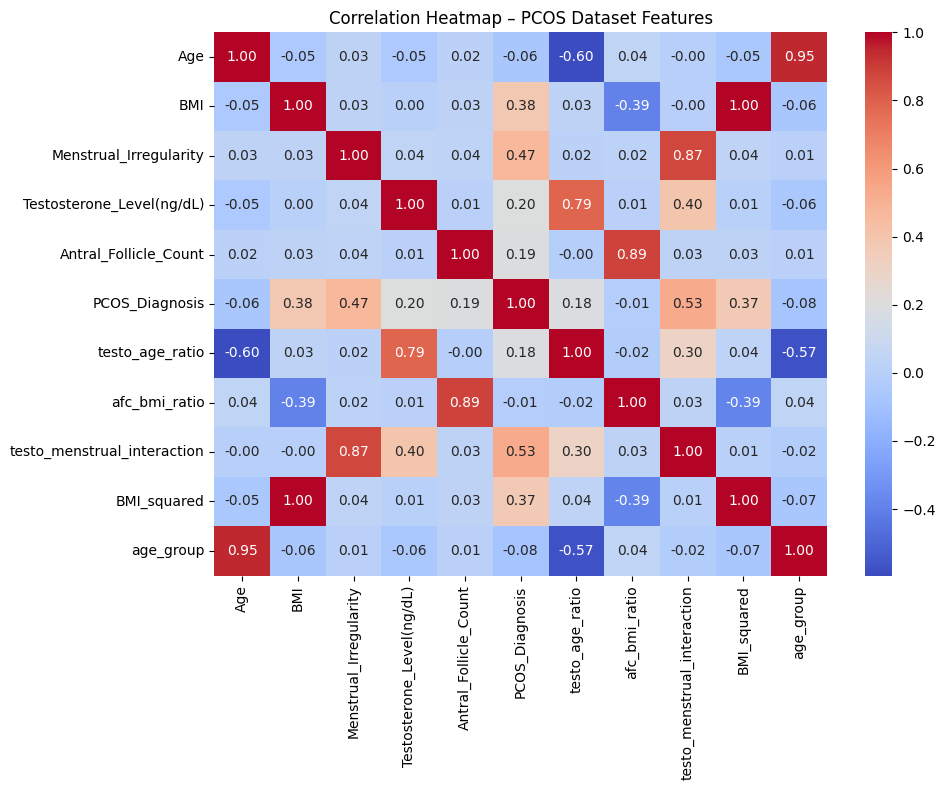

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_pcos.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap – PCOS Dataset Features')
plt.tight_layout()
plt.show()


---
# Part 3: Principal Component Analysis (PCA)
### Dataset: Wine Quality (Red Wine) — continued from Part 2

PCA is a dimensionality reduction technique that transforms correlated features into a smaller set of uncorrelated principal components while retaining maximum variance.


# Step 1: Import Libraries

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix


# Step 2: Prepare Features and Target

In [ ]:
X_wine = df_wine.drop(columns=['quality', 'quality_label'])
y_wine = df_wine['quality_label']

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_wine)

print("Feature matrix shape:", X_scaled.shape)


# Step 3: Fit Full PCA and Plot Cumulative Explained Variance

In [ ]:
pca_full = PCA().fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, color='darkblue', linewidth=1.5)
plt.axhline(0.80, color='red',    linestyle='--', label='80% variance')
plt.axhline(0.90, color='orange', linestyle='--', label='90% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

n_80 = np.searchsorted(cumvar, 0.80) + 1
n_90 = np.searchsorted(cumvar, 0.90) + 1
print(f'Components to retain 80% variance: {n_80}')
print(f'Components to retain 90% variance: {n_90}')


# Step 4: Reduce to 2 Principal Components and Visualise

In [ ]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
var_exp = pca_2d.explained_variance_ratio_

print(f'PC1 explains {var_exp[0]*100:.1f}%  |  PC2 explains {var_exp[1]*100:.1f}%')

y_numeric = y_wine.values

plt.figure(figsize=(8, 6))
for cls, color, label in [(0, 'coral', 'Low Quality'), (1, 'steelblue', 'High Quality')]:
    mask = y_numeric == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label, alpha=0.4, s=20)
plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
plt.title('PCA 2D Projection – Wine Quality')
plt.legend()
plt.tight_layout()
plt.show()


# Step 5: Evaluate with Logistic Regression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_2d, y_numeric, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Quality', 'High Quality'],
            yticklabels=['Low Quality', 'High Quality'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


---
# Part 4: Bag of Words (BoW) Model in NLP
### Dataset: IMDB Movie Reviews
### Source: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In Natural Language Processing (NLP), text data needs to be converted into numbers so that machine learning algorithms can understand it. One common method is the Bag of Words (BoW) model. It turns text into a collection of words and counts how often each word appears, ignoring word order.

**Key Components of BoW**
- Vocabulary: A list of all unique words from the entire dataset.
- Document Representation: Each document is represented as a vector showing the frequency of vocabulary words.


# Step 1: Import Libraries

In [ ]:
import heapq
from wordcloud import WordCloud


# Step 2: Load Dataset and Preprocessing the Text
Before applying the BoW model, we preprocess the text:
- Converting the text to lowercase
- Removing non-word characters
- Removing extra spaces


In [ ]:
print("Upload IMDB Dataset.csv")
uploaded = files.upload()

df_imdb = pd.read_csv('IMDB Dataset.csv')
df_imdb.drop_duplicates(inplace=True)
print("Dataset shape:", df_imdb.shape)
df_imdb.head()


# Step 3: Clean and Tokenise the Text

In [ ]:
# Use a sample of reviews
text = ' '.join(df_imdb['review'].head(100).tolist())

dataset = re.split(r'(?<=[.!?])\s+', text)

cleaned_dataset = []
for sentence in dataset:
    sentence = sentence.lower()
    sentence = re.sub(r'\W', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    cleaned_dataset.append(sentence)

for i, sentence in enumerate(cleaned_dataset[:5]):
    print(f'Sentence {i+1}: {sentence[:80]}...')


# Step 4: Counting Word Frequencies
We count the frequency of each word in the preprocessed text, removing common stop words.


In [ ]:
stop_words = {
    'i','me','my','myself','we','our','ours','ourselves',
    'you','your','yours','yourself','yourselves',
    'he','him','his','himself','she','her','hers','herself',
    'it','its','itself','they','them','their','theirs','themselves',
    'is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did',
    'a','an','the','and','or','but','if','because','as','at','by',
    'for','with','about','against','between','into','through',
    'during','before','after','above','below','to','from',
    'in','out','on','off','over','under','again','further',
    'then','once','here','there','when','where','why','how',
    'all','any','both','each','few','more','most','other','some',
    'such','no','nor','not','only','own','same','so','than','too',
    'very','can','will','just','don','should','now'
}

word2count = {}
for sentence in cleaned_dataset:
    words = sentence.split()
    for word in words:
        if word not in stop_words:
            word2count[word] = word2count.get(word, 0) + 1

word_freq_df = pd.DataFrame(word2count.items(), columns=['Word', 'Frequency'])
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

print('Top Words:')
print(word_freq_df.head(10))

freq_words = heapq.nlargest(10, word2count, key=word2count.get)
print('\nTop 10 words:', freq_words)


# Step 5: Selecting the Most Frequent Words
We select the top 10 most frequent words and visualise with a bar chart.


In [ ]:
top_words = sorted(word2count.items(), key=lambda x: x[1], reverse=True)[:10]
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


# Step 6: Building the Bag of Words Matrix
We build the BoW model as a binary matrix and visualise with a heatmap.


In [ ]:
X_bow = []
for sentence in cleaned_dataset[:20]:
    vector = []
    words = sentence.split()
    for word in freq_words:
        vector.append(1 if word in words else 0)
    X_bow.append(vector)

X_bow = np.array(X_bow)

plt.figure(figsize=(10, 8))
sns.heatmap(
    X_bow,
    cmap='RdYlGn',
    cbar=False,
    annot=True,
    xticklabels=freq_words,
    yticklabels=[f'Sentence {i+1}' for i in range(len(X_bow))]
)
plt.title('Bag of Words Matrix')
plt.xlabel('Frequent Words')
plt.ylabel('Sentences')
plt.tight_layout()
plt.show()


# Step 7: Visualising Word Frequencies with a Word Cloud

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word2count)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.show()


---
# Part 5: Reinforcement Learning – Q-Learning Maze Navigation
### Environment: Custom Maze (no dataset required)

Reinforcement Learning (RL) is a branch of machine learning where an agent learns to make decisions through trial and error to maximise cumulative rewards. The agent interacts with an environment and receives feedback based on its actions.

Key components:
- **Agent**: The decision-maker that performs actions
- **Environment**: The maze the agent navigates
- **State**: The agent's current position in the maze
- **Actions**: Move left, right, up, or down
- **Reward**: +50 for reaching the goal, -10 for hitting a wall, -1 per step


# Step 1: Import Libraries and Define Maze, Start and Goal

In [ ]:
from matplotlib.colors import ListedColormap

maze = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
])

start = (0, 0)
goal  = (9, 9)

print('Maze defined. Start:', start, ' | Goal:', goal)


# Step 2: Define RL Parameters and Initialise Q-Table

- num_episodes: Number of times the agent will attempt to navigate the maze.
- alpha: Learning rate that controls how much new information overrides old information.
- gamma: Discount factor giving more weight to immediate rewards.
- epsilon: Probability of exploration vs exploitation; starts higher to explore more.
- Rewards are set to penalise hitting obstacles, reward reaching the goal and slightly penalise each step.
- actions define possible moves: left, right, up, down.
- Q is the Q-Table initialised to zero; it stores expected rewards for each state-action pair.


In [ ]:
num_episodes = 5000
alpha        = 0.1
gamma        = 0.9
epsilon      = 0.5

reward_wall  = -10
reward_goal  = 50
reward_step  = -1

actions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

Q = np.zeros(maze.shape + (len(actions),))

print('Q-table shape:', Q.shape)


# Step 3: Helper Function for Maze Validity and Action Selection

- is_valid ensures the agent can only move inside the maze and avoids obstacles.
- choose_action implements exploration (random action) vs exploitation (best learned action) strategy.


In [ ]:
def is_valid(pos):
    r, c = pos
    if r < 0 or r >= maze.shape[0]:
        return False
    if c < 0 or c >= maze.shape[1]:
        return False
    if maze[r, c] == 1:
        return False
    return True

def choose_action(state, eps):
    if np.random.random() < eps:
        return np.random.randint(len(actions))
    return np.argmax(Q[state])


## Step 4: Train the Agent with Q-Learning Algorithm

We train the agent by running multiple episodes. During each episode, the agent selects actions and updates its Q-Table using the Q-learning update rule:

Q(s,a) = Q(s,a) + α [ r + γ max Q(s', a') − Q(s,a) ]


In [ ]:
rewards_all_episodes = []

for episode in range(num_episodes):
    state        = start
    total_reward = 0
    done         = False

    while not done:
        action_index = choose_action(state, epsilon)
        action       = actions[action_index]
        next_state   = (state[0] + action[0], state[1] + action[1])

        if not is_valid(next_state):
            reward = reward_wall
            done   = True
        elif next_state == goal:
            reward = reward_goal
            done   = True
        else:
            reward = reward_step

        next_max               = np.max(Q[next_state]) if is_valid(next_state) else 0
        Q[state][action_index] += alpha * (reward + gamma * next_max - Q[state][action_index])

        state        = next_state
        total_reward += reward

    epsilon = max(0.01, epsilon * 0.995)
    rewards_all_episodes.append(total_reward)

print('Training complete.')
print(f'Final epsilon: {epsilon:.4f}')


# Step 5: Extract the Optimal Path after Training

In [ ]:
def get_optimal_path(Q, start, goal, actions, maze, max_steps=200):
    path    = [start]
    state   = start
    visited = set()

    for _ in range(max_steps):
        if state == goal:
            break
        visited.add(state)

        best_action = None
        best_value  = -float('inf')

        for idx, move in enumerate(actions):
            next_state = (state[0] + move[0], state[1] + move[1])
            if (0 <= next_state[0] < maze.shape[0] and
                0 <= next_state[1] < maze.shape[1] and
                maze[next_state] == 0 and
                next_state not in visited):
                if Q[state][idx] > best_value:
                    best_value  = Q[state][idx]
                    best_action = idx

        if best_action is None:
            break

        move  = actions[best_action]
        state = (state[0] + move[0], state[1] + move[1])
        path.append(state)

    return path

optimal_path = get_optimal_path(Q, start, goal, actions, maze)
print(f'Optimal path length: {len(optimal_path)} steps')


# Step 6: Visualise the Maze, Robot Path, Start and Goal

In [ ]:
def plot_maze_with_path(path):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])

    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='#81c784',
                edgecolors='black', s=200, label='Start (Robot)', zorder=5)
    plt.scatter(goal[1], goal[0], marker='*', color='#388e3c',
                edgecolors='black', s=300, label='Goal (Diamond)', zorder=5)

    rows, cols = zip(*path)
    plt.plot(cols, rows, color='#60b37a', linewidth=4, label='Learned Path', zorder=4)

    plt.title('Reinforcement Learning: Robot Maze Navigation')
    plt.gca().invert_yaxis()
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_maze_with_path(optimal_path)


# Step 7: Plot Rewards per Training Episode

In [ ]:
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards)
    plt.title('Total Rewards per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)
    plt.show()

plot_rewards(rewards_all_episodes)
